## IPL franchises Analytics Project ######
The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

### Task 1: Data Understanding

##### Loading the Libraries and Dataset

In [8]:
#Task 1: Data Understanding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [9]:
df=pd.read_csv(r"C:\Users\Gaurav\Downloads\IPL.csv")

##### Basic inspection

In [10]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [29]:
df.tail()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22
73,74,"May 29,2022","Narendra Modi Stadium, Ahmedabad",Gujarat,Rajasthan,Final,Rajasthan,Bat,130,9,133,3,Gujarat,Wickets,7,Hardik Pandya,Shubman Gill,45,Hardik Pandya,3--17


In [30]:
#check dataset shape
df.shape

(74, 20)

In [31]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

In [32]:
df.dtypes

match_id               int64
date                     str
venue                    str
team1                    str
team2                    str
stage                    str
toss_winner              str
toss_decision            str
first_ings_score       int64
first_ings_wkts        int64
second_ings_score      int64
second_ings_wkts       int64
match_winner             str
won_by                   str
margin                 int64
player_of_the_match      str
top_scorer               str
highscore              int64
best_bowling             str
best_bowling_figure      str
dtype: object

In [33]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [35]:
df.size

1480

In [36]:
print(f"your rows are: {df.shape[0]} and your columns are : {df.shape[1]}")

your rows are: 74 and your columns are : 20


In [37]:
#identifying quantitative column
quantitative = df.select_dtypes(include=[np.number])
quantitative.columns

Index(['match_id', 'first_ings_score', 'first_ings_wkts', 'second_ings_score',
       'second_ings_wkts', 'margin', 'highscore'],
      dtype='str')

In [38]:
#identifying qualitative column
qualitative = df.select_dtypes(exclude=[np.number])
qualitative.columns

Index(['date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'match_winner', 'won_by', 'player_of_the_match',
       'top_scorer', 'best_bowling', 'best_bowling_figure'],
      dtype='str')

### Task 2: Exploratory Data Analysis (EDA)

#### Univariate Analysis

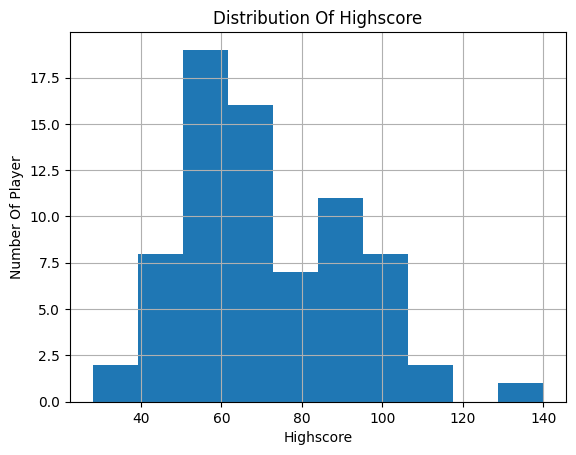

In [19]:
import matplotlib.pyplot as plt

df['highscore'].hist()
plt.xlabel("Highscore")
plt.ylabel("Number Of Player")
plt.title("Distribution Of Highscore")
plt.show()

#Histogram

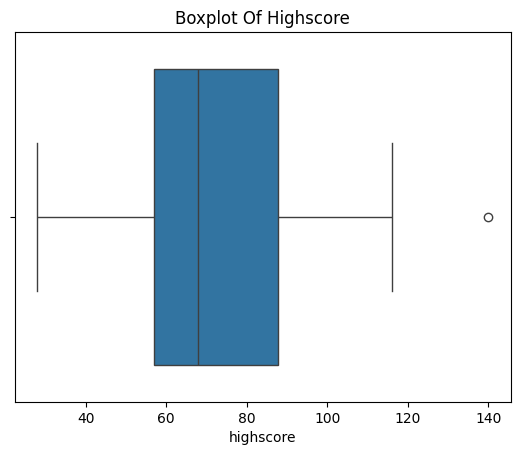

In [5]:
import seaborn as sns
sns.boxplot(x=df['highscore'])
plt.title("Boxplot Of Highscore")
plt.show()

#Boxplot

#### Bivariate Analysis

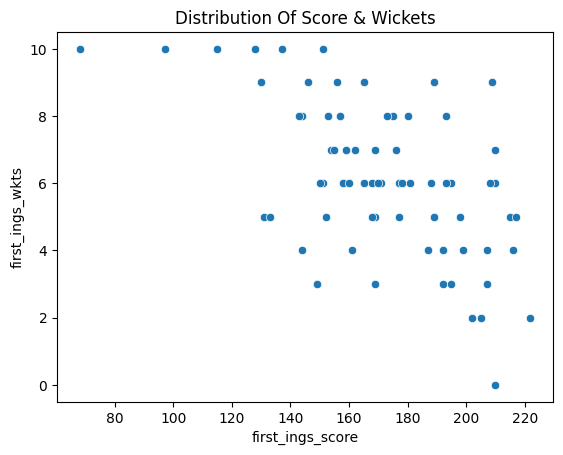

In [26]:
sns.scatterplot(x='first_ings_score', y='first_ings_wkts', data=df)
plt.title("Distribution Of Score & Wickets")
plt.show()

#Scatterplot

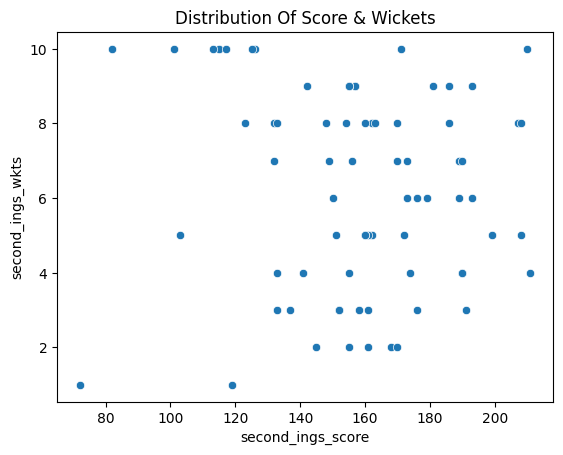

In [27]:
sns.scatterplot(x='second_ings_score', y='second_ings_wkts', data=df)
plt.title("Distribution Of Score & Wickets")
plt.show()

#Scatterplot

### Correlation Matrix

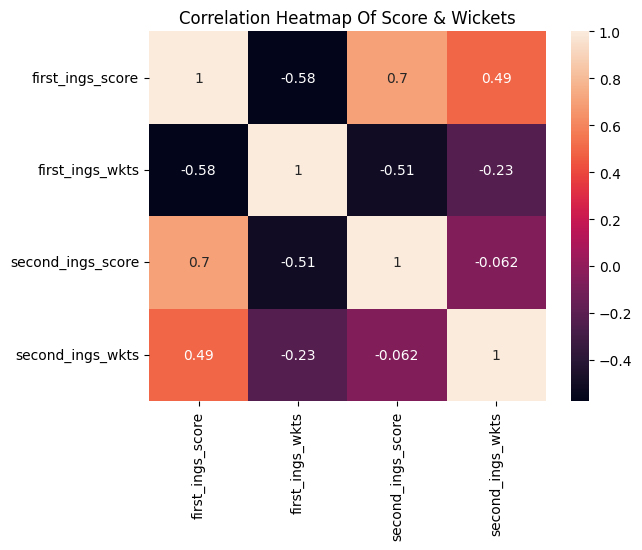

In [28]:
sns.heatmap(df[['first_ings_score',	'first_ings_wkts',	'second_ings_score', 'second_ings_wkts']].corr(), annot=True)
plt.title("Correlation Heatmap Of Score & Wickets")
plt.show()

### Multivariate Analysis

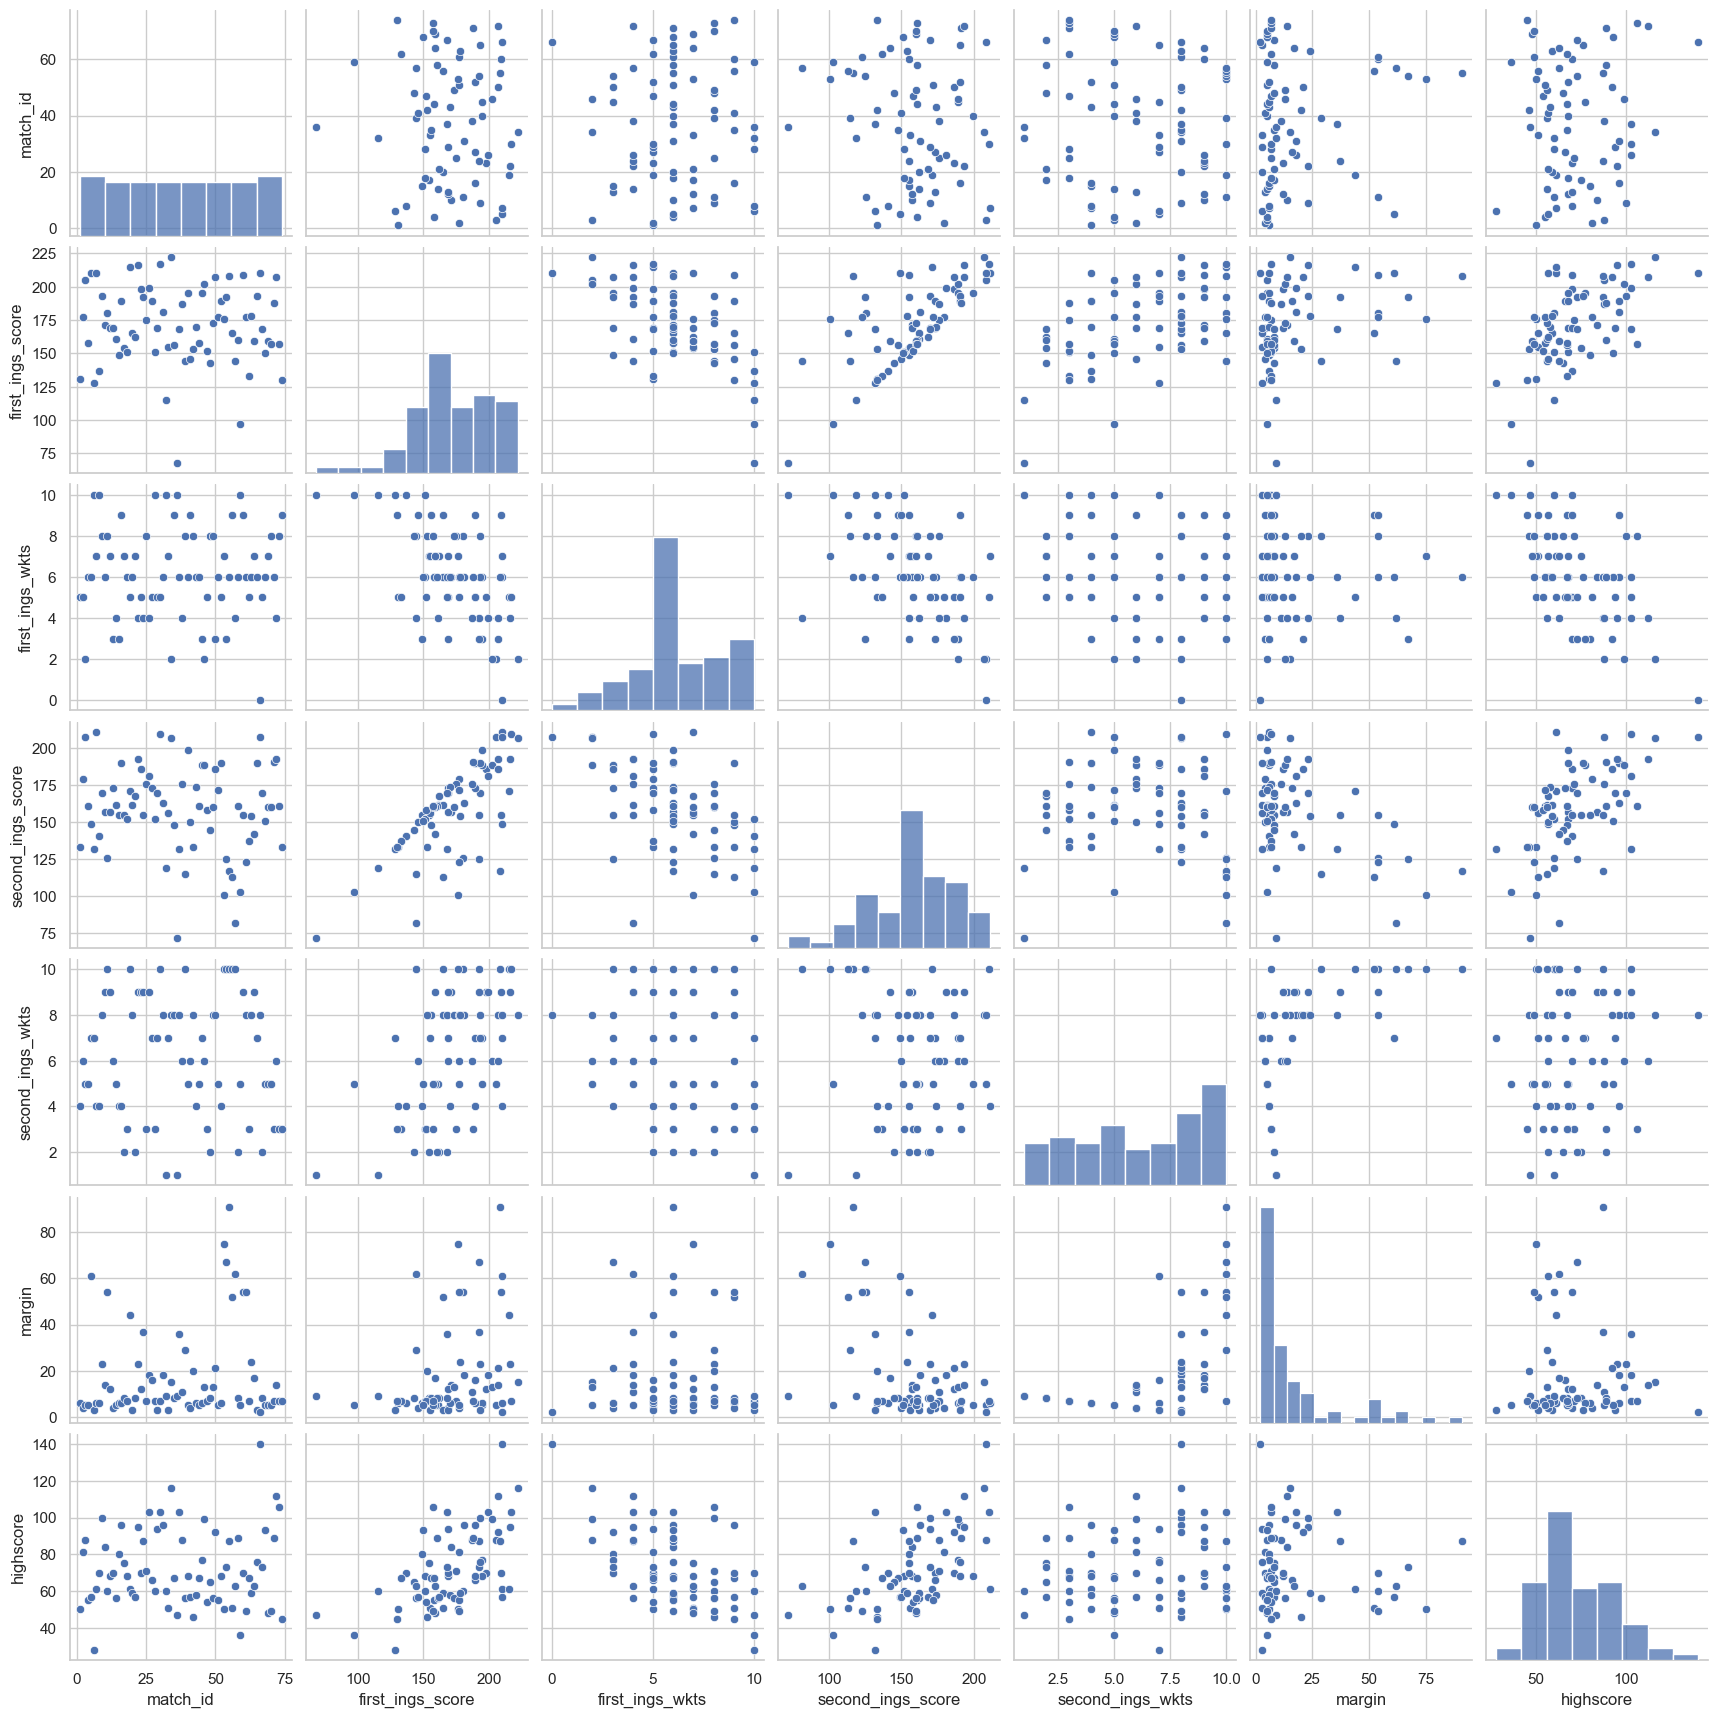

In [53]:
sns.pairplot(df)
plt.show()

### Task 3: Missing Values & Outliers

In [54]:
#Check missing values

df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [55]:
#Fill missing values

df.fillna(df.mean(numeric_only=True), inplace=True)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


Text(0.5, 1.0, 'Boxplot for Detecting Outliers in Team1')

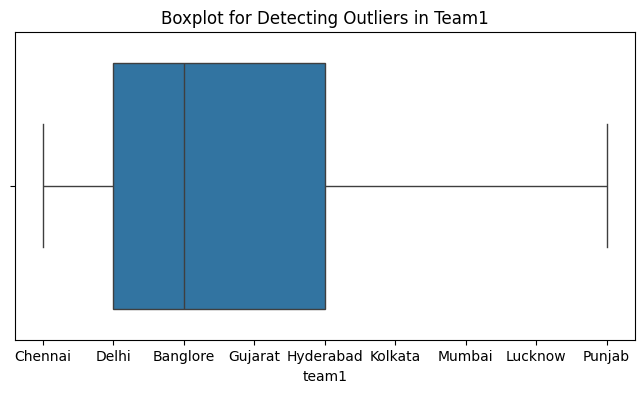

In [35]:
#Detect outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df['team1'])
plt.title("Boxplot for Detecting Outliers in Team1")


### Task 4: Spread of Data

In [81]:
df[['first_ings_score','first_ings_wkts','second_ings_score','second_ings_wkts','highscore']].describe()

,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000
mean,171.121622,6.135135,158.540541,6.175676,71.716216
std,29.048355,2.222699,29.299207,2.639832,20.705052
min,68.000000,0.000000,72.000000,1.000000,28.000000
25%,154.250000,5.000000,142.750000,4.000000,57.000000
50%,169.500000,6.000000,160.000000,6.000000,68.000000
75%,192.750000,8.000000,176.000000,8.000000,87.750000
max,222.000000,10.000000,211.000000,10.000000,140.000000


In [83]:
df[['first_ings_score','first_ings_wkts','second_ings_score','second_ings_wkts','highscore']].mean()
df[['first_ings_score','first_ings_wkts','second_ings_score','second_ings_wkts','highscore']].median()
df[['first_ings_score','first_ings_wkts','second_ings_score','second_ings_wkts','highscore']].std()
df[['first_ings_score','first_ings_wkts','second_ings_score','second_ings_wkts','highscore']].skew()
df[['first_ings_score','first_ings_wkts','second_ings_score','second_ings_wkts','highscore']].kurt()

first_ings_score     1.204502
first_ings_wkts     -0.204401
second_ings_score    0.429913
second_ings_wkts    -1.132079
highscore            0.495687
dtype: float64

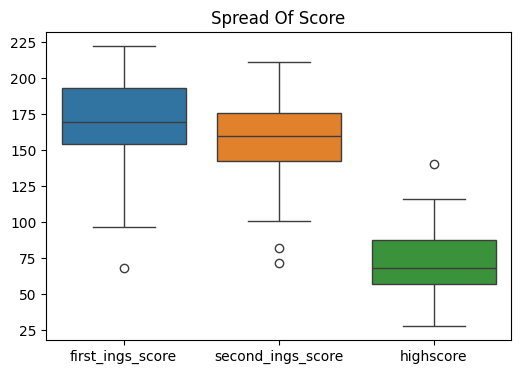

In [36]:
#boxplot for spread visualization

plt.figure(figsize=(6,4))
sns.boxplot(data=df[['first_ings_score','second_ings_score','highscore']])
plt.title("Spread Of Score")
plt.show()

#### Task 5: Automating EDA

In [97]:
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [102]:
def eda_summary(data):
    print(data.describe())
    print(data.isnull().sum())

#### TASK 6&7: REGRESSION ANALYSIS

In [114]:
#covariance analysis

df[['first_ings_score','first_ings_wkts','second_ings_score','second_ings_wkts','highscore']].cov()

,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,highscore
first_ings_score,843.806923,-37.126250,599.371714,37.567382,344.637727
first_ings_wkts,-37.126250,4.940392,-33.005553,-1.339134,-25.851536
second_ings_score,599.371714,-33.005553,858.443539,-4.767494,338.374676
second_ings_wkts,37.567382,-1.339134,-4.767494,6.968715,8.036838
highscore,344.637727,-25.851536,338.374676,8.036838,428.699185


In [115]:
#corellation analysis

df[['first_ings_score','first_ings_wkts','second_ings_score','second_ings_wkts','highscore']].corr()

,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,highscore
first_ings_score,1.000000,-0.575015,0.704237,0.489906,0.573014
first_ings_wkts,-0.575015,1.000000,-0.506816,-0.228227,-0.561732
second_ings_score,0.704237,-0.506816,1.000000,-0.061639,0.557783
second_ings_wkts,0.489906,-0.228227,-0.061639,1.000000,0.147039
highscore,0.573014,-0.561732,0.557783,0.147039,1.000000


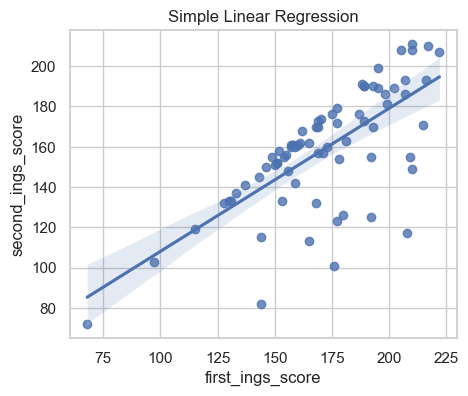

In [119]:
#Regression
plt.figure(figsize=(5,4))
sns.regplot(x='first_ings_score', y='second_ings_score', data=df)
plt.title("Simple Linear Regression")
plt.show()

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['match_id']]
y = df['highscore']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [122]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [124]:
y_pred = model.predict(X_test)

#### Task 8: Model Evaluation

In [125]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

564.0050580357758
17.415896071138476
-0.013716913168212885


#### Task 9: Data Visualization

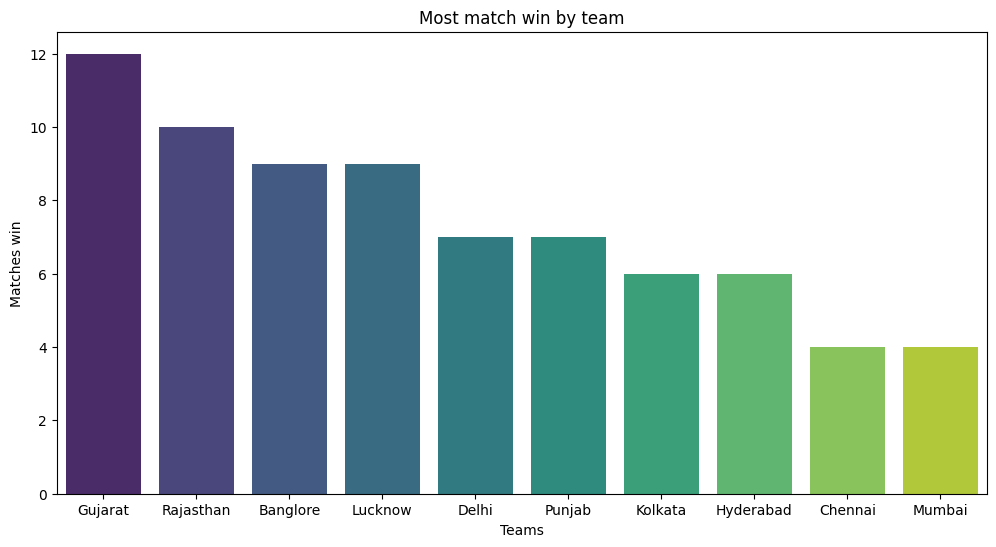

In [46]:
match_wins = df["match_winner"].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(x = match_wins.index, y = match_wins.values , palette= "viridis")

plt.title("Most match win by team")
plt.xlabel("Teams")
plt.ylabel('Matches win')
plt.show()


In [48]:
df['toss_decision'].value_counts()

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

Text(0.5, 1.0, 'Toss Decision Trends')

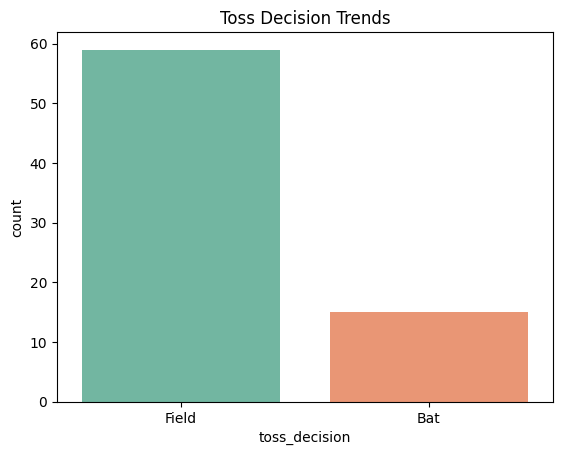

In [49]:
sns.countplot(data = df, x="toss_decision", palette = "Set2")
plt.title("Toss Decision Trends")

### Toss Winner vs Match Winner

In [51]:
df["toss_winner"].value_counts()

toss_winner
Gujarat      10
Hyderabad    10
Mumbai        9
Kolkata       8
Delhi         8
Banglore      8
Lucknow       7
Chennai       6
Punjab        4
Rajasthan     4
Name: count, dtype: int64

In [52]:
df["match_winner"].value_counts()

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

In [53]:
count = df[df['toss_winner'] == df['match_winner']][["toss_winner","match_winner"]]
count

,toss_winner,match_winner
0,Kolkata,Kolkata
1,Delhi,Delhi
2,Punjab,Punjab
3,Gujarat,Gujarat
5,Banglore,Banglore
6,Lucknow,Lucknow
7,Kolkata,Kolkata
12,Banglore,Banglore
13,Kolkata,Kolkata
14,Lucknow,Lucknow


In [55]:
df['won_by'].value_counts()

won_by
Wickets    37
Runs       37
Name: count, dtype: int64

In [56]:
#sns.countplot(x= df["won_by"])

Text(0, 0.5, 'Number of Matches')

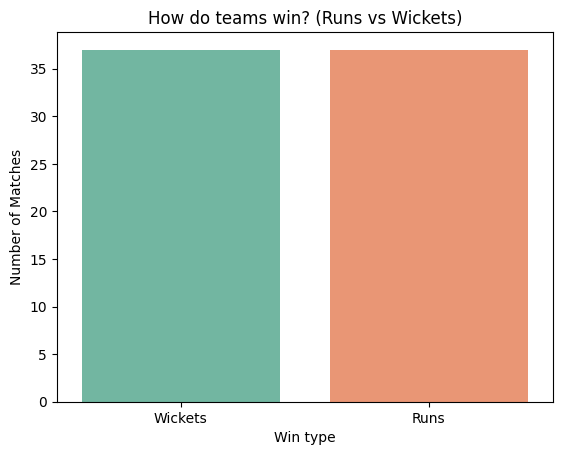

In [57]:
sns.countplot(data=df, x = "won_by", palette= 'Set2')

plt.title("How do teams win? (Runs vs Wickets)")
plt.xlabel('Win type')
plt.ylabel('Number of Matches')

### Key Player Performances

In [59]:
#Most "Player of the Match" Awards

pom_df = df['player_of_the_match'].value_counts().head(10)

Text(0, 0.5, 'Man of the Man Awards')

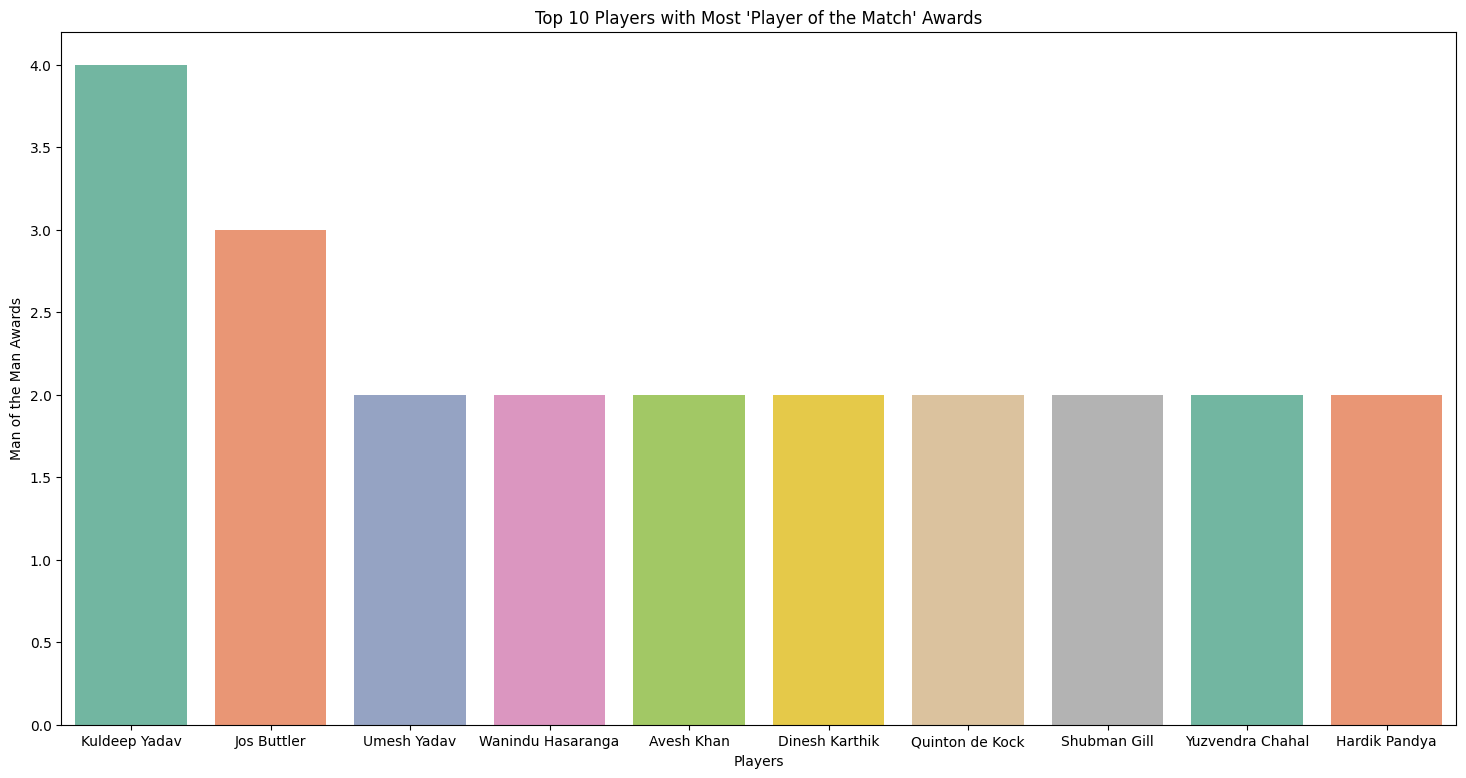

In [60]:
plt.figure(figsize=(18,9))
sns.barplot(x = pom_df.index, y = pom_df.values, palette = 'Set2')
plt.title("Top 10 Players with Most 'Player of the Match' Awards")
plt.xlabel('Players')
plt.ylabel('Man of the Man Awards')

In [62]:
df["top_scorer"].value_counts().head(2)

top_scorer
Jos Buttler        7
Quinton de Kock    5
Name: count, dtype: int64

In [63]:
# we are using top scorer and high scorer

In [64]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

Text(0, 0.5, 'Runs')

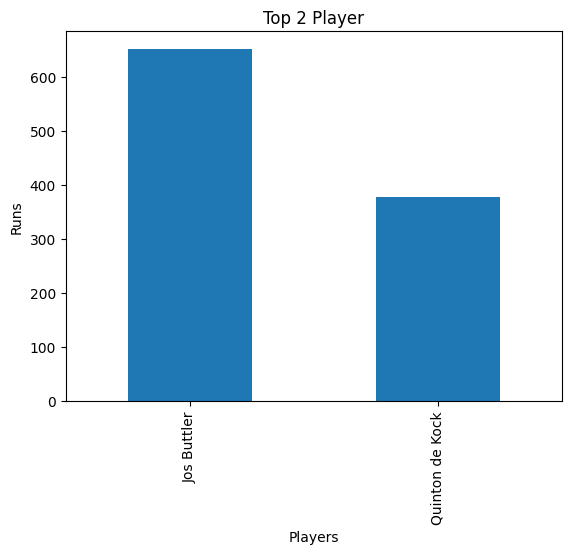

In [65]:
high.plot(kind= 'bar')
plt.title("Top 2 Player")
plt.xlabel("Players")
plt.ylabel("Runs")

In [66]:
# 10 Best Bowling Figure

In [68]:
df[["best_bowling"]].value_counts().head(10).sort_values(ascending=False)

best_bowling    
Yuzvendra Chahal    5
Rashid Khan         4
Kuldeep Yadav       3
Jasprit Bumrah      3
Avesh Khan          3
T Natarajan         3
Josh Hazlewood      3
Kagiso Rabada       3
Dwayne Bravo        2
Mohammed Shami      2
Name: count, dtype: int64

In [69]:
df["highest_wickets"] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df["highest_wickets"] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby("best_bowling")['highest_wickets'].sum().sort_values(ascending=False).head(10)

In [70]:
top_bowlers

best_bowling
Yuzvendra Chahal     17
Jasprit Bumrah       11
Kuldeep Yadav        11
Rashid Khan          11
Josh Hazlewood       10
Kagiso Rabada        10
Avesh Khan           10
Umran Malik           9
Wanindu Hasaranga     9
T Natarajan           8
Name: highest_wickets, dtype: int64

Text(0, 0.5, 'Total Wickets')

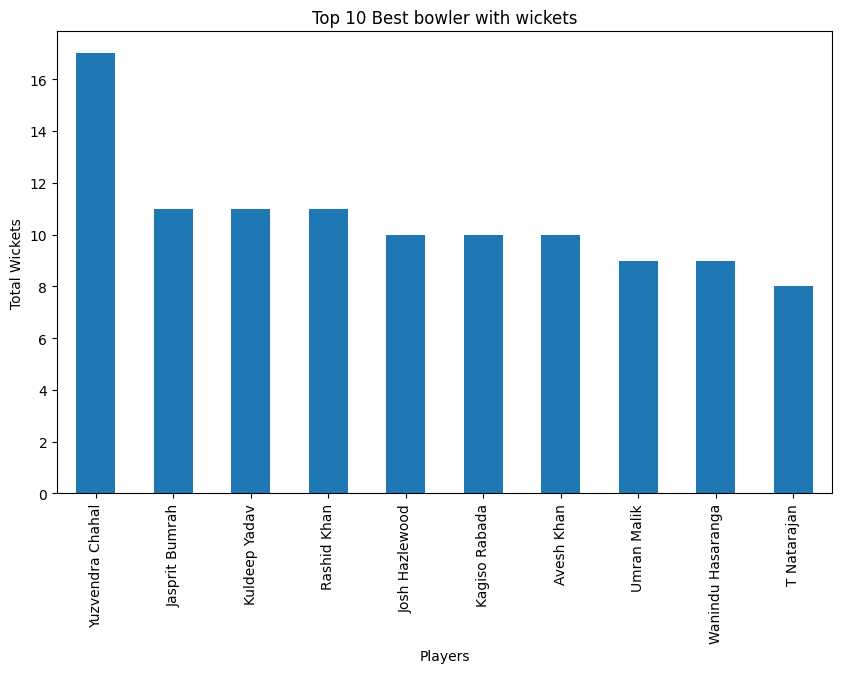

In [71]:
plt.figure(figsize= (10,6))
top_bowlers.plot(kind = 'bar')
plt.title("Top 10 Best bowler with wickets")
plt.xlabel('Players')
plt.ylabel('Total Wickets')


### Venue Analysis

In [73]:
#Most Matches Played by Venue

venue_count = df['venue'].value_counts()

In [74]:
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

Text(0, 0.5, 'Venue')

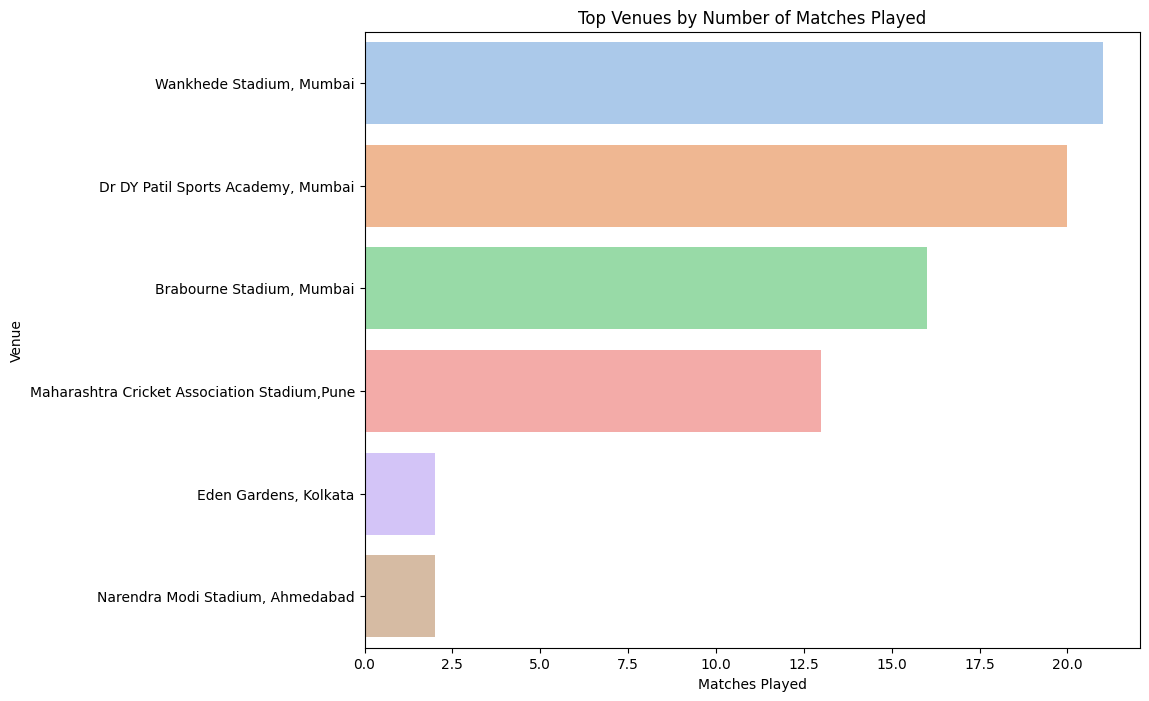

In [75]:
plt.figure(figsize=(10,8))
sns.barplot( x = venue_count.values, y = venue_count.index, palette = "pastel")
plt.title('Top Venues by Number of Matches Played')
plt.xlabel("Matches Played")
plt.ylabel("Venue")


In [77]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin', ascending=False).head(1)[['match_winner', 'margin']]

,match_winner,margin
54,Chennai,91


Q2: Which player had the highest individual score?

In [78]:
df[df['highscore'] == df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Q3: Which bowler had the best bowling figures?

In [79]:
df[df['highest_wickets'] == df['highest_wickets'].max()][["best_bowling","best_bowling_figure"]]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
